## Nivel 1

**Ejercicio 1**

- Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el archivo se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.
- Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.
- Muestra las primeras 10 filas.
- Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.

In [277]:
import pandas as pd

df = pd.read_excel("/Users/valeriaontaneda/Documents/It_Academy/Especializacion/Sprint 10/Sprint10.xlsx", skiprows= 2, header = 1, index_col=0)
df = df.sort_values(["País d'origen", "Ciutat"])
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.00,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.00,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.00,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.00,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.00,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.00,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.00,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.00,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.00,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.00,Grup B


In [278]:
df["DNI"].is_unique # no duplicates in the DNI column

True

**Ejercicio 2**
- Crea una columna que sea el nombre completo.
- Crea una columna si la persona ha nacido en España o no.
- Pone el DNI como índice del DataFrame (nombres de filas).
- Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.
- Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).
- Muestra todos los cambios que has realizado en una sola tabla.

In [279]:
df["Nom complet"] = df["Nom"] + " " + df["Cognoms"]
df["Nascuda a Espanya"] = df["País d'origen"] == "Espanya"
df = df.set_index('DNI')
df = df.rename(columns={'Dia de Naixement': 'Dia', 'Mes de Naixement': 'Mes', "Any de Naixement": "Any"})
df = df.replace(['H', 'D', 'A', 'NC'], ['Home', 'Dona', 'Altres', 'null'])

df.head(10)


,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascuda a Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,NaN,1.00,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,1.00,NaN,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,NaN,1.00,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,1.00,NaN,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,1.00,NaN,Grup D,Jonas Schneider,False
14773153R,Lea,Fischer,Alemanya,Berlín,9,9,1986,Dona,1.370 €,1.00,NaN,Grup A,Lea Fischer,False
23266650S,Lea,Müller,Alemanya,Hamburg,14,4,2003,Dona,1.314 €,NaN,1.00,Grup A,Lea Müller,False
83274277X,Anna,Müller,Alemanya,Hamburg,1,1,1987,Dona,2.464 €,NaN,1.00,Grup C,Anna Müller,False
60161784X,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,null,2.035 €,1.00,NaN,Grup C,Laura Schmidt Müller,False


**Ejercicio 3**
- Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. 
- La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".

In [280]:
df["Fills"] = df["Fills"].apply(lambda x: "Si" if x > 0 else "No")
df.drop(["No Fills"], axis = 1, inplace = True)
df.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Nascuda a Espanya
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951 €,No,Grup A,Mia Schneider Fischer,False
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1.769 €,Si,Grup B,Laura Schneider Fischer,False
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2.013 €,No,Grup B,Lea Schneider Schneider,False
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1.557 €,Si,Grup B,Mia Fischer,False
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2.754 €,Si,Grup D,Jonas Schneider,False


**Ejercicio 4**
- Crea una tabla resumen que permita ver el sueldo promedio, mediana, mínimo y máximo por Género.
- Ordena la tabla en función del sueldo mediana.

In [281]:
# Salary clean up and change to integer to be able to do aggregations
df["Salari mensual"] = df["Salari mensual"].str.replace(r"[€.]", "", regex=True)
df["Salari mensual"] = df["Salari mensual"].astype("f")

In [282]:
salary_overview_df = df.groupby("Gènere")[["Salari mensual"]].agg(["mean","median","min","max"]).round(2)
salary_overview_df = salary_overview_df.sort_values(("Salari mensual", "mean"), ascending=False)
salary_overview_df

Salari mensual                       
                 mean  median    min     max
Gènere                                      
Home          1643.25 1531.00 737.00 3356.00
Altres        1626.59 1545.00 703.00 3175.00
null          1568.87 1443.00 758.00 2969.00
Dona          1469.44 1361.50 665.00 3021.00

**Ejercicio 5**
- Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).
- Añade las medias a los márgenes de la mesa.
- (EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

In [283]:
salary_country = pd.crosstab(df["Gènere"],df["País d'origen"],df["Salari mensual"],aggfunc= "mean", margins=True, margins_name="Mitjana general").round(2)
salary_country.head()

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana general
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
null,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
Mitjana general,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


In [284]:
salary_country.style.format("{:.2f}").background_gradient(cmap="Purples")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana general
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
null,1931.50,1135.67,1252.00,1597.14,1573.00,1316.00,1365.50,1583.00,1553.50,1758.00,1568.87
Mitjana general,1858.35,1431.68,1489.13,1582.16,1465.36,1421.17,1441.69,1559.08,1527.23,1448.33,1561.46


**Ejercicio 6**
- Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.
- Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

In [285]:
from datetime import datetime

def calculate_age(birthdate):
    return (datetime.now() - birthdate).days // 365 # Using .days to get only days out of the difference using // to get a whole number

df["Data de naixament"] = df[["Any", "Mes", "Dia"]].apply(lambda x: datetime(x["Any"], x["Mes"], x["Dia"]), axis = 1) # Using datetime to get birthdate using 3 columns and apply with a lambda function to change it in each row with axis = 1

df["Edat"] = df["Data de naixament"].apply(calculate_age)
df.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Nascuda a Espanya,Data de naixament,Edat
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.00,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.00,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.00,No,Grup B,Lea Schneider Schneider,False,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.00,Si,Grup B,Mia Fischer,False,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.00,Si,Grup D,Jonas Schneider,False,1985-11-22,40


## Nivel 2

**Ejercicio 1**
- Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.
- Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

In [286]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment": ["5%","3,5%","2%","8%"]})
df_increment.head()

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [287]:
df = df.reset_index()
df_merged = pd.merge(df, df_increment, left_on = "Grup Professional", right_on = "Grup", how="left")
df_merged.drop(["Grup"], axis = 1, inplace = True)
df_merged = df_merged.set_index('DNI')
df_merged.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Nascuda a Espanya,Data de naixament,Edat,Increment
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,951.00,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49,5%
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1769.00,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,68,"3,5%"
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2013.00,No,Grup B,Lea Schneider Schneider,False,2005-10-23,20,"3,5%"
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1557.00,Si,Grup B,Mia Fischer,False,1950-08-11,75,"3,5%"
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2754.00,Si,Grup D,Jonas Schneider,False,1985-11-22,40,8%


In [288]:
def salary_increment(salary, increment_percentage):
    increment = float(increment_percentage.replace("%","").replace(",","."))
    salary_increase = round(salary * ((increment/100)+1), 2)
    return salary_increase

df_merged["Salari mensual"] = df_merged[["Salari mensual", "Increment"]].apply(lambda row: salary_increment(row["Salari mensual"], row["Increment"]), axis = 1)
df_merged.head(10)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom complet,Nascuda a Espanya,Data de naixament,Edat,Increment
DNI,,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Altres,998.55,No,Grup A,Mia Schneider Fischer,False,1976-10-22,49,5%
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Dona,1830.91,Si,Grup B,Laura Schneider Fischer,False,1958-02-02,68,"3,5%"
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Dona,2083.45,No,Grup B,Lea Schneider Schneider,False,2005-10-23,20,"3,5%"
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Dona,1611.49,Si,Grup B,Mia Fischer,False,1950-08-11,75,"3,5%"
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Home,2974.32,Si,Grup D,Jonas Schneider,False,1985-11-22,40,8%
14773153R,Lea,Fischer,Alemanya,Berlín,9,9,1986,Dona,1438.50,Si,Grup A,Lea Fischer,False,1986-09-09,39,5%
23266650S,Lea,Müller,Alemanya,Hamburg,14,4,2003,Dona,1379.70,No,Grup A,Lea Müller,False,2003-04-14,23,5%
83274277X,Anna,Müller,Alemanya,Hamburg,1,1,1987,Dona,2513.28,No,Grup C,Anna Müller,False,1987-01-01,39,2%
60161784X,Laura,Schmidt Müller,Alemanya,Hamburg,15,6,1987,null,2075.70,Si,Grup C,Laura Schmidt Müller,False,1987-06-15,39,2%


**Ejercicio 2**

- Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional. Por ejemplo: "datos_GrupA.xlsx" , "datos_GrupB.xlsx" ...
- Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

In [289]:
def save_group_info():
    group_array = df_merged["Grup Professional"].unique()
    for group in group_array:
        filtered_df = df_merged.loc[df_merged["Grup Professional"] == group, : ]
        filtered_df.to_csv(f"{group}_info")

save_group_info()

In [290]:
Grupos_info_general_df = df_merged.groupby("Grup Professional")[["Nom", "Salari mensual", "Edat"]].agg({"Nom" : "size", "Salari mensual" : "mean", "Edat" : "median"}).round(2) #CAMBIAR A COUNT
Grupos_info_general_df = Grupos_info_general_df.rename(columns={"Nom" : "Worker_count", "Salari mensual" : "Salary_mean", "Edat" : "Age_median"})
Grupos_info_general_df["Age_median"] = Grupos_info_general_df["Age_median"].astype("i")
Grupos_info_general_df.to_csv("Grupos_info_general") 
Grupos_info_general_df.head()

,Worker_count,Salary_mean,Age_median
Grup Professional,,,
Grup A,490,1213.32,51
Grup B,318,1724.55,48
Grup C,137,2289.19,52
Grup D,55,3100.82,44


## Nivel 3

**Ejercicio 1**

- Crea una función que tome un dataframe como parámetro de entrada. \
La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

    - un histograma/boxplot si la variable es numérica
    - unas barras de los valores más frecuentes si es categórica
    - unas barras de los años más frecuentes si el dato está en formato fecha.
- La idea es crear una función que funcione por cualquier dataframe, no sólo con lo que hemos trabajado hasta ahora.
- Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris , penguins o titanic .
- Ten en consideración que en el siguiente sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear gráficos muy elaborados, sino resolver una necesidad de forma rápida y automática.

In [291]:
import seaborn as sns
penguins_df = sns.load_dataset("penguins")
penguins_df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10,18.70,181.00,3750.00,Male
1,Adelie,Torgersen,39.50,17.40,186.00,3800.00,Female
2,Adelie,Torgersen,40.30,18.00,195.00,3250.00,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.70,19.30,193.00,3450.00,Female


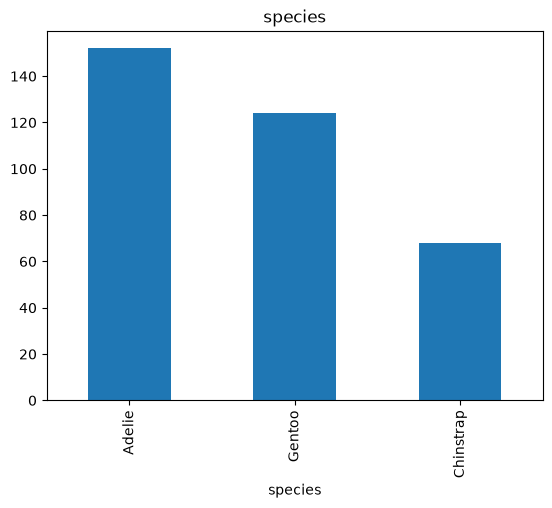

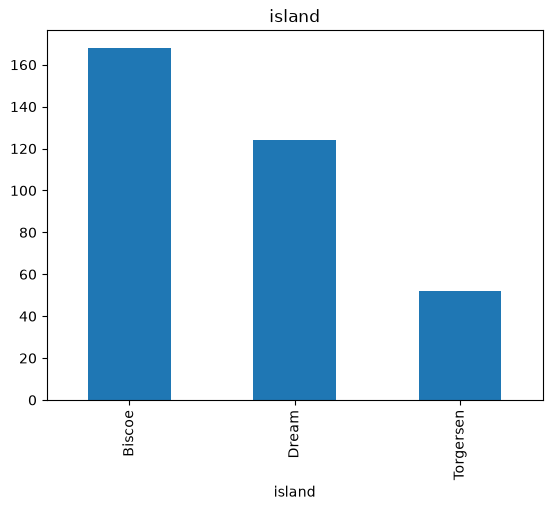

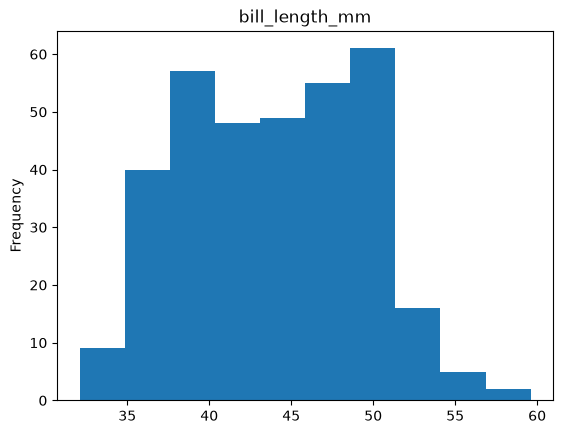

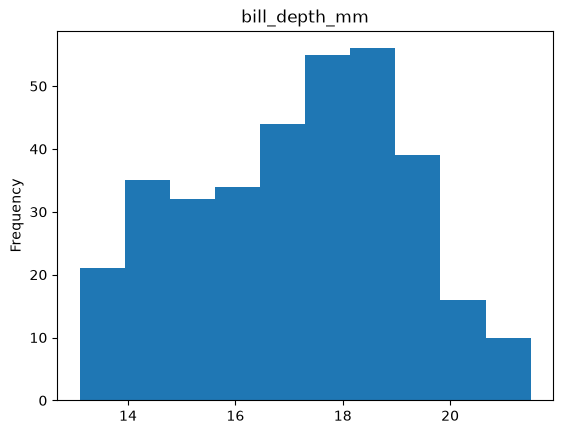

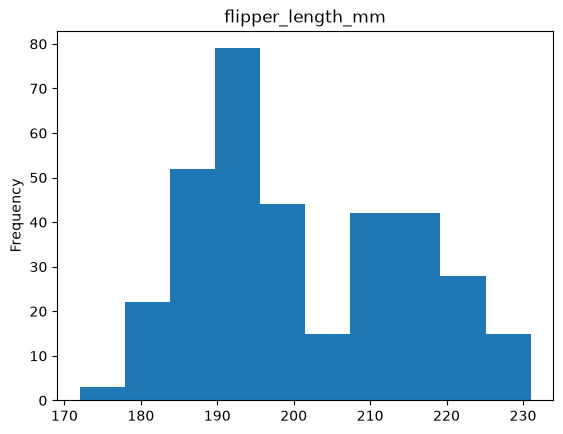

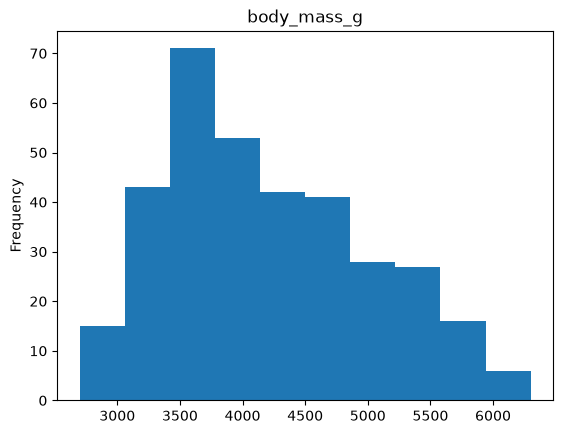

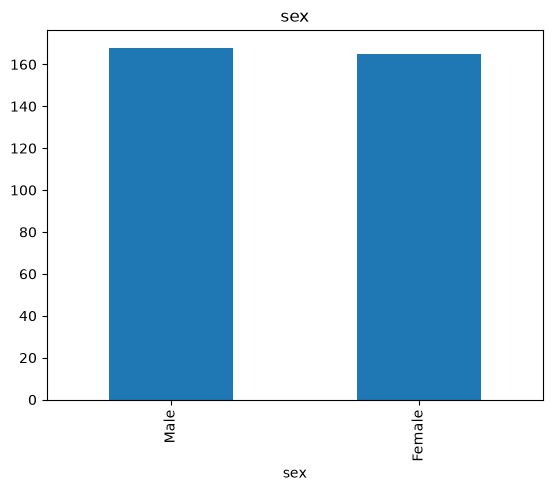

In [293]:
import matplotlib.pyplot as plt

def creating_visualizations(df):
    for column_name, values in df.items():
        plt.figure() 
        plt.title(column_name)

        if pd.api.types.is_bool_dtype(values):
            values.value_counts().plot.pie()
        elif pd.api.types.is_string_dtype(values):
            values.value_counts().head(20).plot.bar()
        elif pd.api.types.is_numeric_dtype(values):
            values.plot.hist()
        elif pd.api.types.is_datetime64_any_dtype(values):
            values.dt.year.value_counts().head(20).sort_index().plot.bar()
        else:
            plt.close()
            continue
    
        plt.savefig(f"{column_name}.png")
        plt.show()

creating_visualizations(penguins_df)


**Ejercicio 2**

Carga el archivo matriz_distancies.xlsx en pandas, de modo que los nombres de filas y los nombres de columnas sean los de las ciudades. Borra "Las Palmas de Gran Canaria" y "Palma" para que podamos realizar el trayecto en coche.

Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

No hace falta que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.

Por ejemplo, una aproximación sencilla (que no óptima) sería yendo siempre a la ciudad más cercana que no hayamos visitado todavía

Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, devolviendo una lista con el orden de visita. Da también la distancia total recorrida.

(EXTRA) Desde qué ciudad la ruta sería más corta con el algoritmo planteado

In [294]:
distance_df = pd.read_excel("/Users/valeriaontaneda/Documents/It_Academy/Especializacion/Sprint 10/matriu_distancies.xlsx", index_col=0)
distance_df.drop(["Palma", "Las Palmas de Gran Canaria"], inplace = True)
distance_df.drop(["Palma", "Las Palmas de Gran Canaria"], axis=1, inplace = True)
distance_df.head(20)

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.00,831.00,256.00,770.00,471.00,469.00,407.00,711.00,576.00,908.00,686.00,7.00
Valencia,303.00,NaN,541.00,246.00,468.00,177.00,473.00,125.00,421.00,441.00,766.00,632.00,297.00
Sevilla,831.00,541.00,NaN,646.00,158.00,433.00,703.00,495.00,121.00,486.00,588.00,685.00,824.00
Zaragoza,256.00,246.00,646.00,NaN,628.00,408.00,246.00,368.00,535.00,320.00,652.00,444.00,250.00
Málaga,770.00,468.00,158.00,628.00,NaN,323.00,739.00,391.00,133.00,549.00,716.00,766.00,763.00
Murcia,471.00,177.00,433.00,408.00,323.00,NaN,606.00,69.00,320.00,510.00,800.00,726.00,465.00
Bilbao,469.00,473.00,703.00,246.00,739.00,606.00,NaN,583.00,618.00,232.00,486.00,223.00,465.00
Alicante,407.00,125.00,495.00,368.00,391.00,69.00,583.00,NaN,379.00,515.00,821.00,722.00,401.00
Córdoba,711.00,421.00,121.00,535.00,133.00,320.00,618.00,379.00,NaN,419.00,589.00,634.00,704.00
Valladolid,576.00,441.00,486.00,320.00,549.00,510.00,232.00,515.00,419.00,NaN,337.00,224.00,570.00


In [295]:
def creating_route(city, df = distance_df):
    route = [city] 
    next_city = city 
    nearest_city = "" #variable to be used in for loop to capture the nearest city. This will keep changing until the loop is done and the lowest distance with its city is saved
    total_distance = 0 
    while len(route) < len(df.columns): #using a while to keep launching the for loop until the route covers the column's length
        lowest_distance = float('inf') #starting a variable to save the lowest distance between origin city/next_city and all other cities
        for column in df.columns: 
            distance = float(df.loc[next_city, column])
            if distance < lowest_distance and column not in route: #using an if to save the lowest distance and also ensuring the city is not duplicated in the route
                lowest_distance = distance
                nearest_city = column
        total_distance += lowest_distance
        next_city = nearest_city #save the nearest_city under next_city once for is done
        route.append(next_city) #adding city to the route
    return route, total_distance


def fastest_route_origin_city(df = distance_df):
    lowest_distance = float('inf')
    for column in df.columns:
        route_list, total_distance = creating_route(column)
        if total_distance < lowest_distance:
            lowest_distance = total_distance
            city_name = column
    return city_name, lowest_distance
        
city_of_origen = "Vigo"

route_list, total_distance = creating_route(city_of_origen)

shortest_route_list, shortest_total_distance = fastest_route_origin_city()

print("Route:", route_list)
print("Total distance:", total_distance)
print("Shortest route starts with", shortest_route_list, "and covers the following distance:", shortest_total_distance)

Route: ['Vigo', 'Gijón', 'Bilbao', 'Valladolid', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Hospitalet de Llobregat', 'Barcelona']
Total distance: 2873.0
Shortest route starts with Barcelona and covers the following distance: 2778.0
